In [18]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
%matplotlib inline

from score_function import clustering_score

In [19]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=200, facecolor='white')

In [20]:
def clustering_score(original_adata, score_value = 'bic', clustering_algorithm='leiden', dim_reduction = 'pca', min_res=0.1, max_res=2.0, step=0.1, plot=True):
    #calinski_harabasz
    import numpy as nu
    import scanpy as sc
    import pandas as pd
    from sklearn.metrics import calinski_harabasz_score

    sc.settings.verbosity = 0

    if dim_reduction == 'pca':
        dim_reduction = 'X_pca'
    elif dim_reduction == 'umap':
        dim_reduction = 'X_umap'
    else:
        print('please choose pca or umap as dimensionality reduction')
        exit

    res = list(nu.arange(min_res,max_res,step))
    score = []
    n_clus = []

    for r in res:
        index = res.index(r)
        adata = original_adata.copy()
        string_r = str(r)
        clustering_name = '%s_res%s' %(clustering_algorithm,string_r)
        print('Clustering by using the resolution %.2f, step %i of %i' %(r,index+1,len(res)))
        if clustering_algorithm == 'leiden':
            sc.tl.leiden(adata, key_added="%s_res%s" %(clustering_algorithm,string_r), resolution=r)
        elif clustering_algorithm == 'louvain':
            sc.tl.louvain(adata, key_added="%s_res%s" %(clustering_algorithm,string_r), resolution=r)
        else:
            print('please choose louvain or leiden as clustering_algorithm')
            exit
        if score_value == 'bic':
            score_name = 'BIC score'
            n_points = len(adata.obs[clustering_name])
            n_clusters = len(set(adata.obs[clustering_name]))
            n_dimensions = adata.obsm[dim_reduction].shape[1]

            n_parameters = (n_clusters - 1) + (n_dimensions * n_clusters) + 1

            loglikelihood=0
            for cluster_id in set(adata.obs[clustering_name]):
                cluster_mask = (adata.obs[clustering_name] == cluster_id)
                X_cluster = adata.obsm[dim_reduction][cluster_mask]

                n_points_cluster = len(X_cluster)
                centroid = nu.mean(X_cluster, axis=0)
                variance = nu.sum((X_cluster - centroid) ** 2) / (len(X_cluster) - 1)
                loglikelihood += \
                  n_points_cluster * nu.log(n_points_cluster) \
                  - n_points_cluster * nu.log(n_points) \
                  - n_points_cluster * n_dimensions / 2 * nu.log(2 * nu.pi * variance) \
                  - (n_points_cluster - 1) / 2

            bic = loglikelihood - (n_parameters / 2) * nu.log(n_points)
            bic = -2*bic
            score.append(bic)
            n_clus.append(n_clusters)

            del adata.obs[clustering_name]
        
        elif score_value == 'calinski':
            score_name = 'Calinski-Harabasz score'
            n_clusters = len(set(adata.obs[clustering_name]))
            n_clus.append(n_clusters)
            score.append(-1*calinski_harabasz_score(adata.obsm[dim_reduction], adata.obs[clustering_name]))
            

    df = pd.DataFrame()
    df[score_name] = score
    df['resolution'] = res
    df['n_clus'] = n_clus

    if plot==True:
        df.plot(x='resolution',y=score_name)
    print('\n')

    return df, res[nu.argmin(score)]

## Paul15

In [21]:
adata = sc.read_h5ad("/shared/projects/spatial_cell_id_merfish/clustering_optimum/datasets/paul15/processed_data.h5ad")

Clustering by using the resolution 0.10, step 1 of 24
Clustering by using the resolution 0.20, step 2 of 24
Clustering by using the resolution 0.30, step 3 of 24
Clustering by using the resolution 0.40, step 4 of 24
Clustering by using the resolution 0.50, step 5 of 24
Clustering by using the resolution 0.60, step 6 of 24
Clustering by using the resolution 0.70, step 7 of 24
Clustering by using the resolution 0.80, step 8 of 24
Clustering by using the resolution 0.90, step 9 of 24
Clustering by using the resolution 1.00, step 10 of 24
Clustering by using the resolution 1.10, step 11 of 24
Clustering by using the resolution 1.20, step 12 of 24
Clustering by using the resolution 1.30, step 13 of 24
Clustering by using the resolution 1.40, step 14 of 24
Clustering by using the resolution 1.50, step 15 of 24
Clustering by using the resolution 1.60, step 16 of 24
Clustering by using the resolution 1.70, step 17 of 24
Clustering by using the resolution 1.80, step 18 of 24
Clustering by using

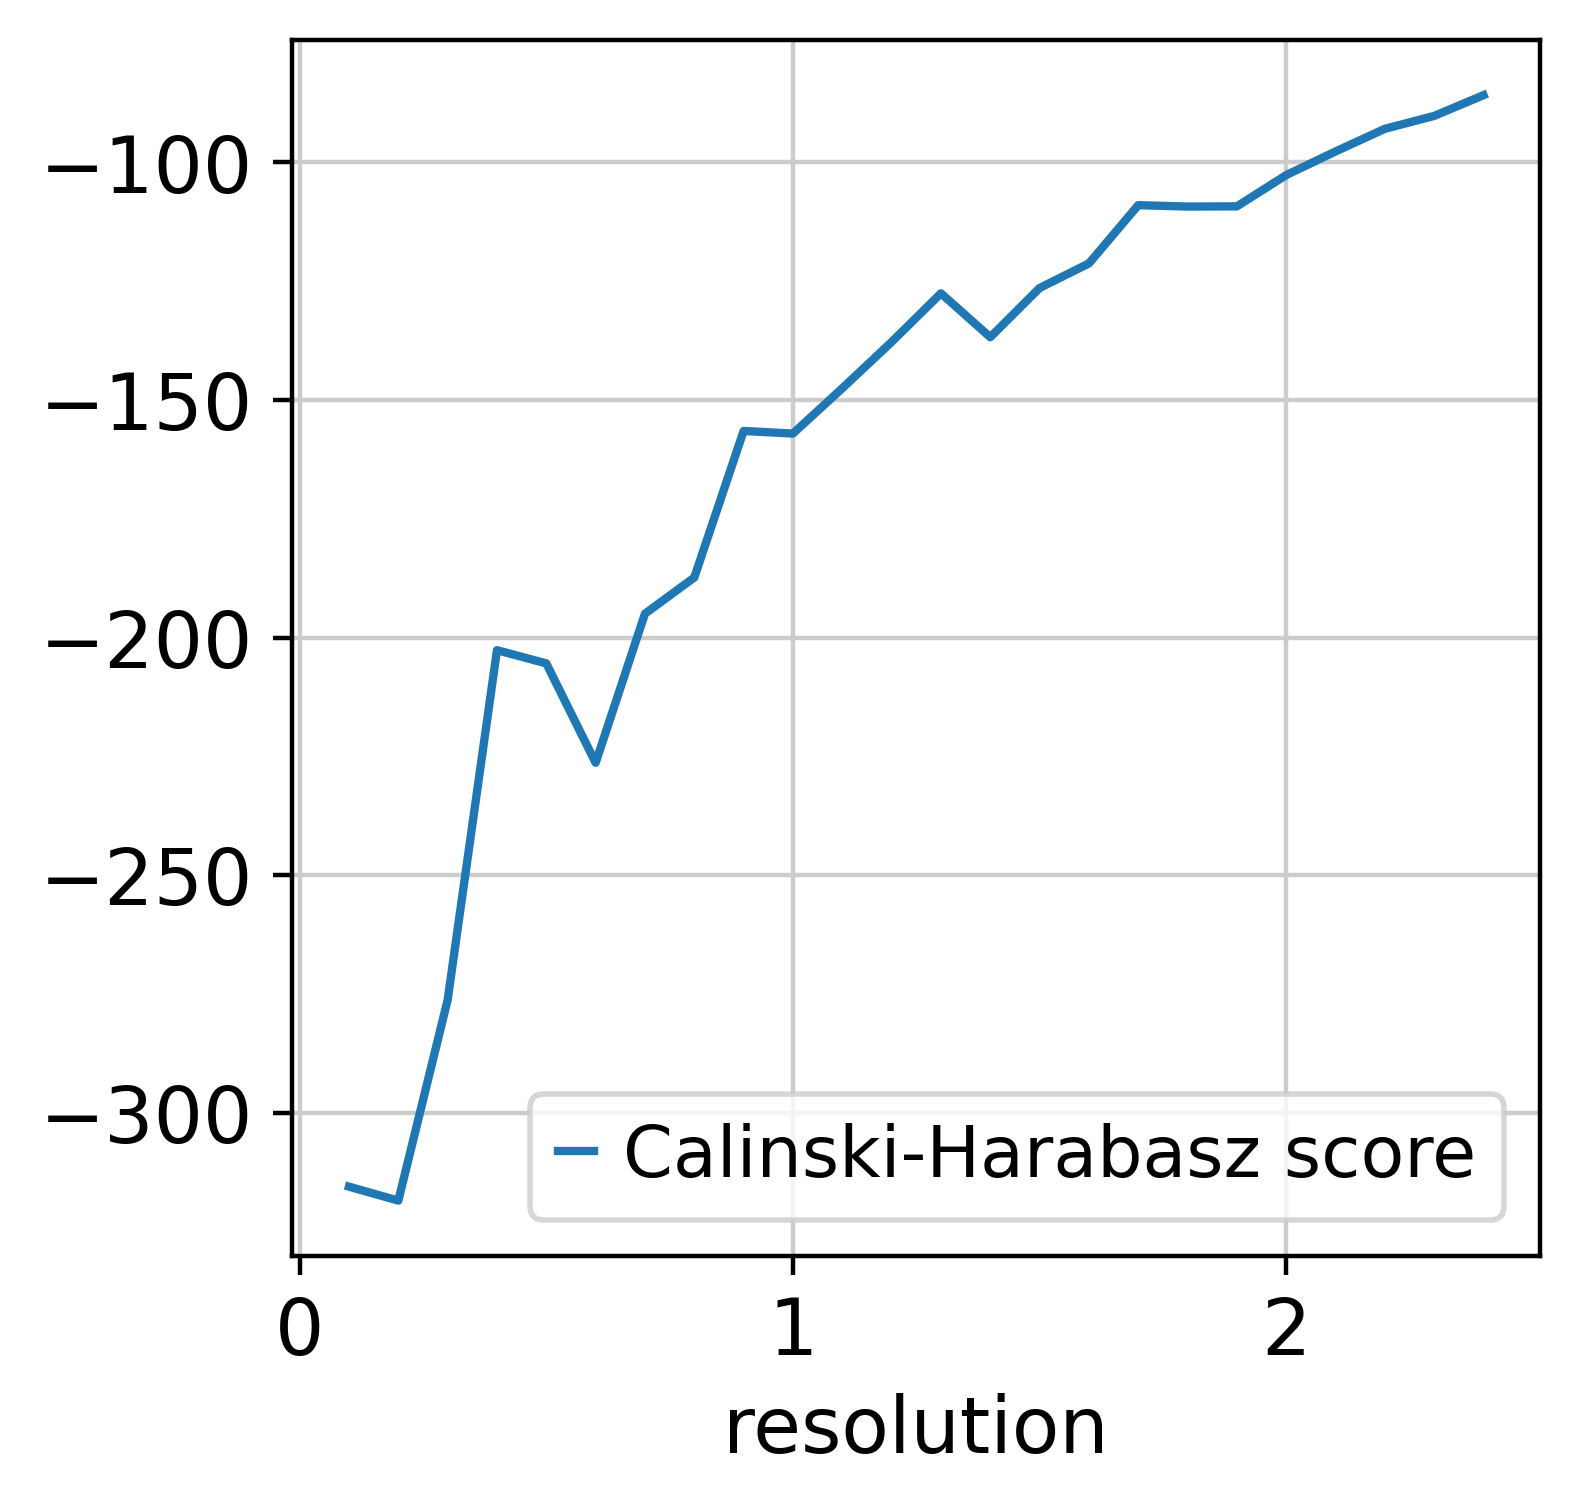

In [27]:
a = clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'pca')

In [28]:
a[0]
a[1]

0.2

Clustering by using the resolution 0.10, step 1 of 24
Clustering by using the resolution 0.20, step 2 of 24
Clustering by using the resolution 0.30, step 3 of 24
Clustering by using the resolution 0.40, step 4 of 24
Clustering by using the resolution 0.50, step 5 of 24
Clustering by using the resolution 0.60, step 6 of 24
Clustering by using the resolution 0.70, step 7 of 24
Clustering by using the resolution 0.80, step 8 of 24
Clustering by using the resolution 0.90, step 9 of 24
Clustering by using the resolution 1.00, step 10 of 24
Clustering by using the resolution 1.10, step 11 of 24
Clustering by using the resolution 1.20, step 12 of 24
Clustering by using the resolution 1.30, step 13 of 24
Clustering by using the resolution 1.40, step 14 of 24
Clustering by using the resolution 1.50, step 15 of 24
Clustering by using the resolution 1.60, step 16 of 24
Clustering by using the resolution 1.70, step 17 of 24
Clustering by using the resolution 1.80, step 18 of 24
Clustering by using

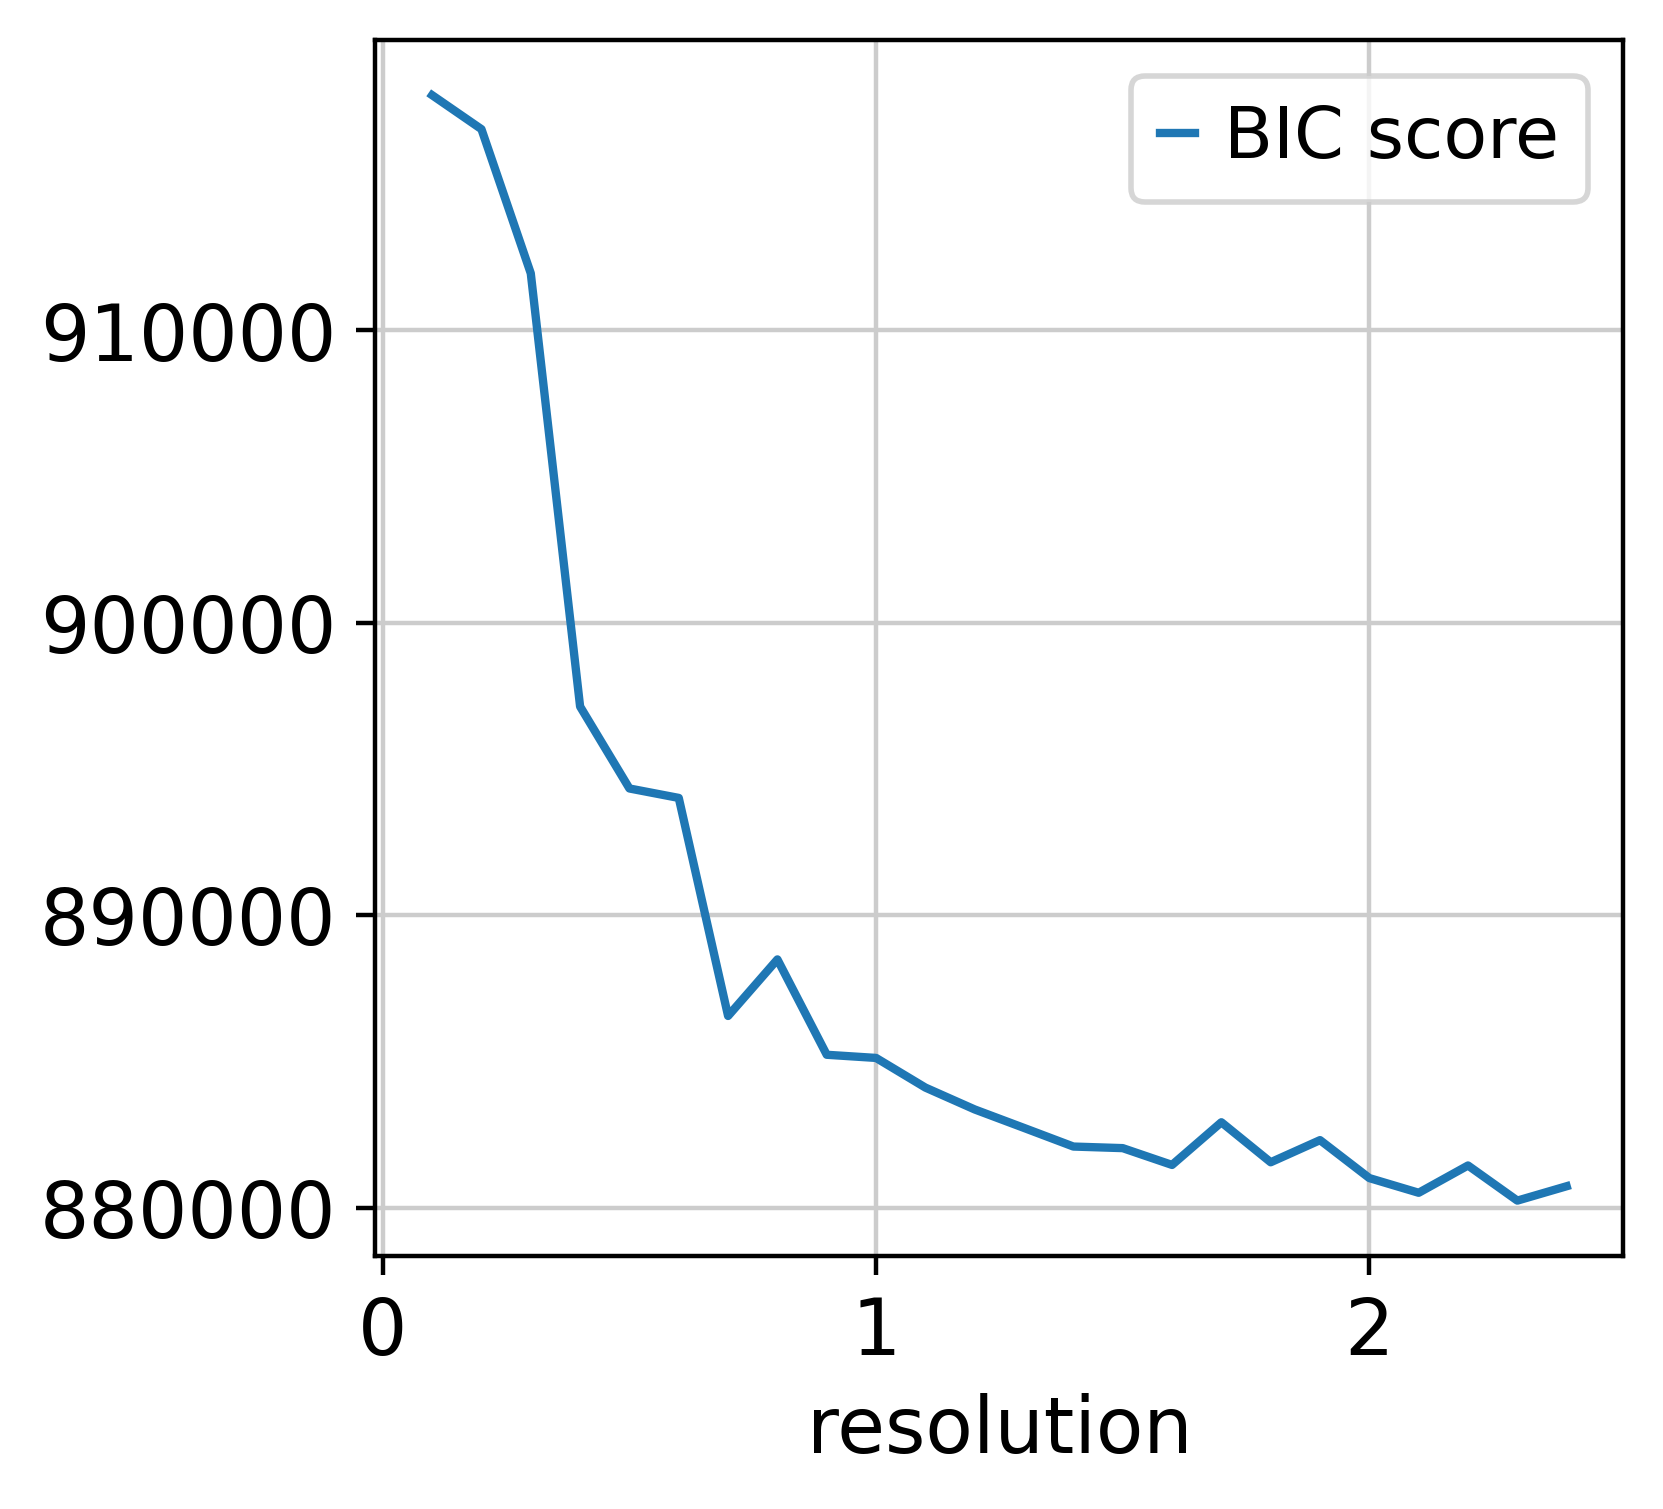

In [29]:
b = clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'pca')

In [30]:
b[0]
b[1]

2.3000000000000003

Clustering by using the resolution 0.10, step 1 of 24
Clustering by using the resolution 0.20, step 2 of 24
Clustering by using the resolution 0.30, step 3 of 24
Clustering by using the resolution 0.40, step 4 of 24
Clustering by using the resolution 0.50, step 5 of 24
Clustering by using the resolution 0.60, step 6 of 24
Clustering by using the resolution 0.70, step 7 of 24
Clustering by using the resolution 0.80, step 8 of 24
Clustering by using the resolution 0.90, step 9 of 24
Clustering by using the resolution 1.00, step 10 of 24
Clustering by using the resolution 1.10, step 11 of 24
Clustering by using the resolution 1.20, step 12 of 24
Clustering by using the resolution 1.30, step 13 of 24
Clustering by using the resolution 1.40, step 14 of 24
Clustering by using the resolution 1.50, step 15 of 24
Clustering by using the resolution 1.60, step 16 of 24
Clustering by using the resolution 1.70, step 17 of 24
Clustering by using the resolution 1.80, step 18 of 24
Clustering by using

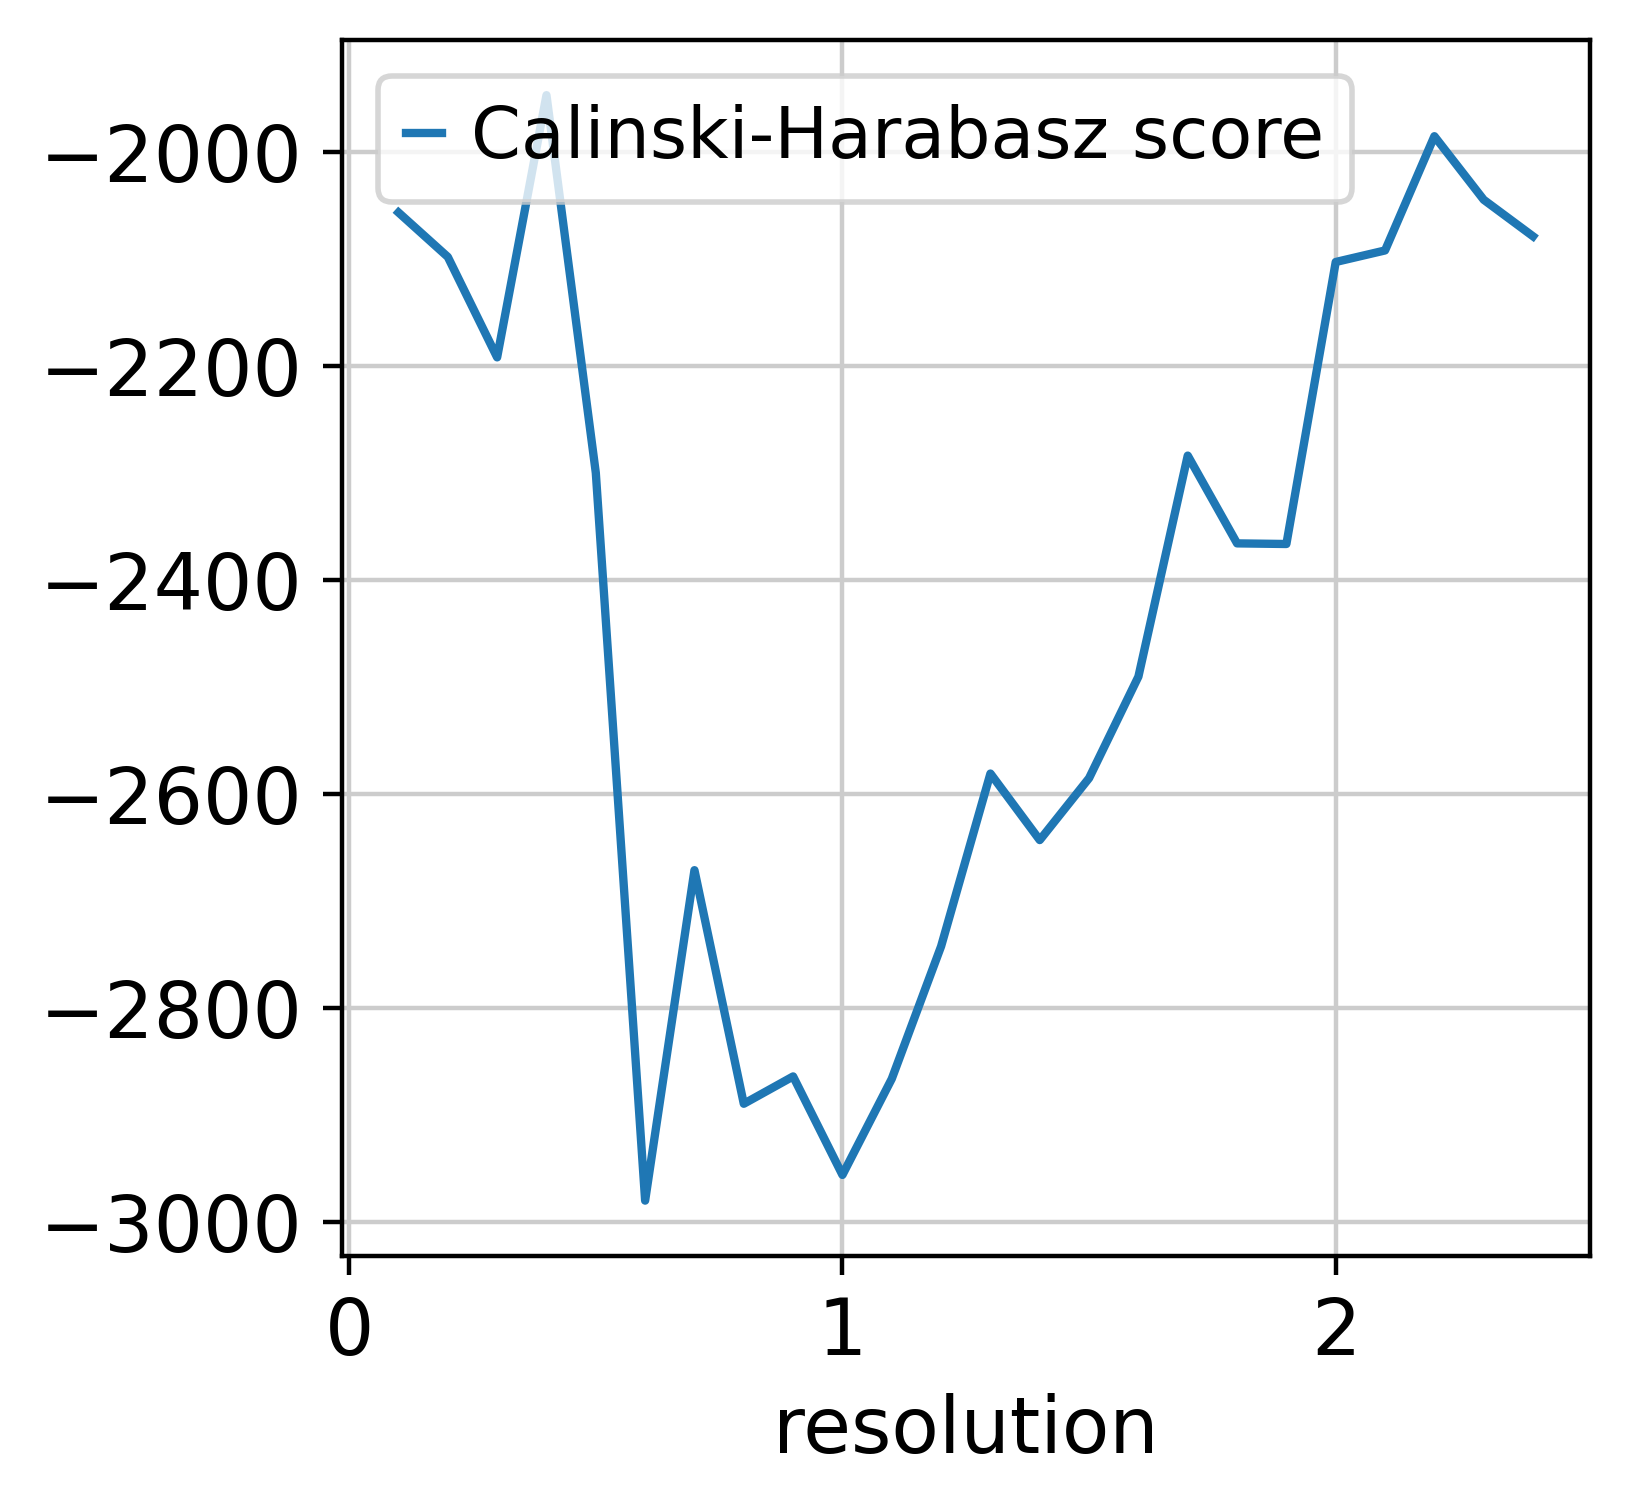

In [31]:
c = clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'umap')

In [32]:
c[0]
c[1]

0.6

Clustering by using the resolution 0.10, step 1 of 24
Clustering by using the resolution 0.20, step 2 of 24
Clustering by using the resolution 0.30, step 3 of 24
Clustering by using the resolution 0.40, step 4 of 24
Clustering by using the resolution 0.50, step 5 of 24
Clustering by using the resolution 0.60, step 6 of 24
Clustering by using the resolution 0.70, step 7 of 24
Clustering by using the resolution 0.80, step 8 of 24
Clustering by using the resolution 0.90, step 9 of 24
Clustering by using the resolution 1.00, step 10 of 24
Clustering by using the resolution 1.10, step 11 of 24
Clustering by using the resolution 1.20, step 12 of 24
Clustering by using the resolution 1.30, step 13 of 24
Clustering by using the resolution 1.40, step 14 of 24
Clustering by using the resolution 1.50, step 15 of 24
Clustering by using the resolution 1.60, step 16 of 24
Clustering by using the resolution 1.70, step 17 of 24
Clustering by using the resolution 1.80, step 18 of 24
Clustering by using

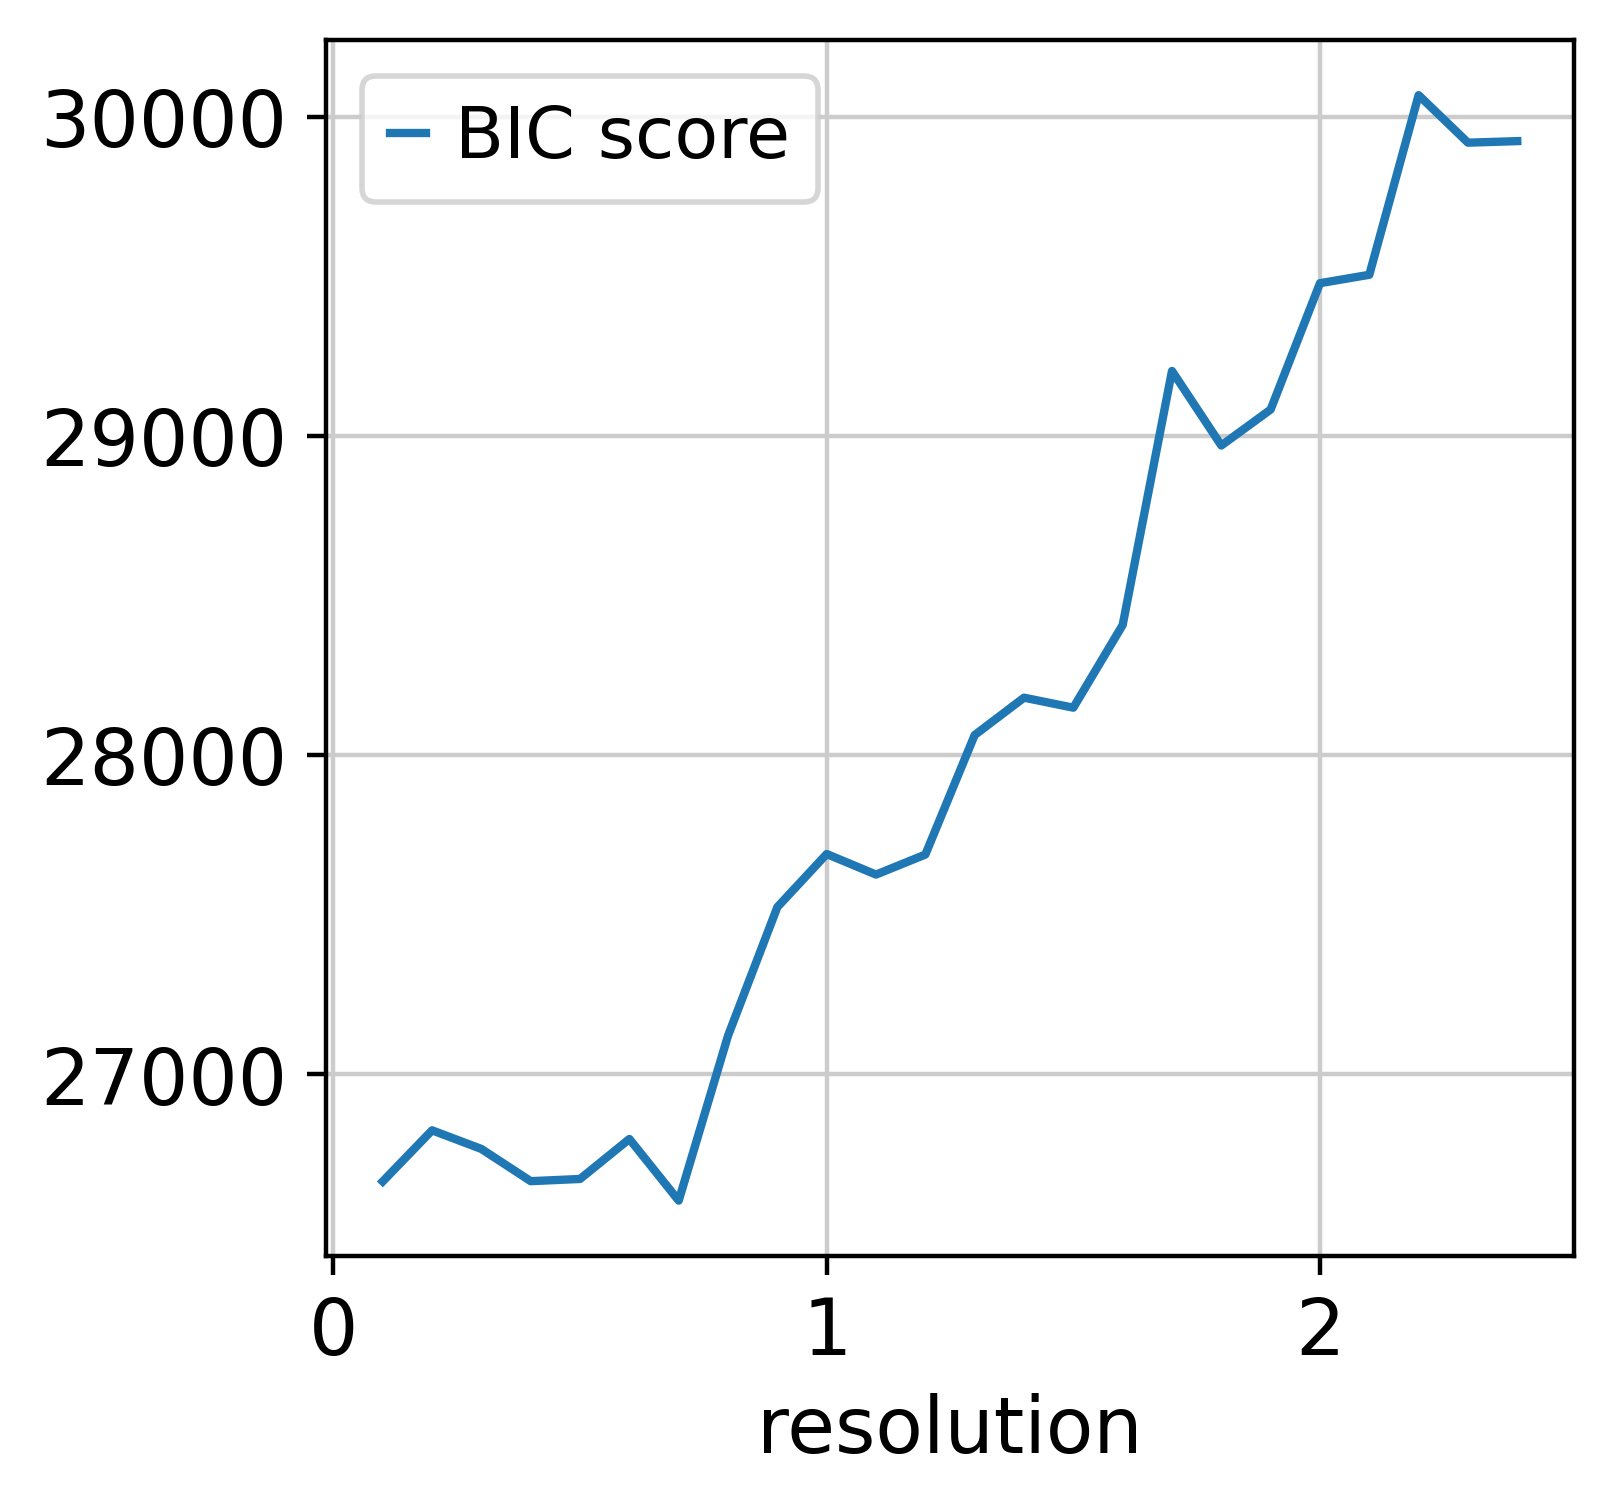

In [33]:
d = clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'umap')

In [34]:
d[0]
d[1]

0.7000000000000001

/shared/home/ssarnata/.conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


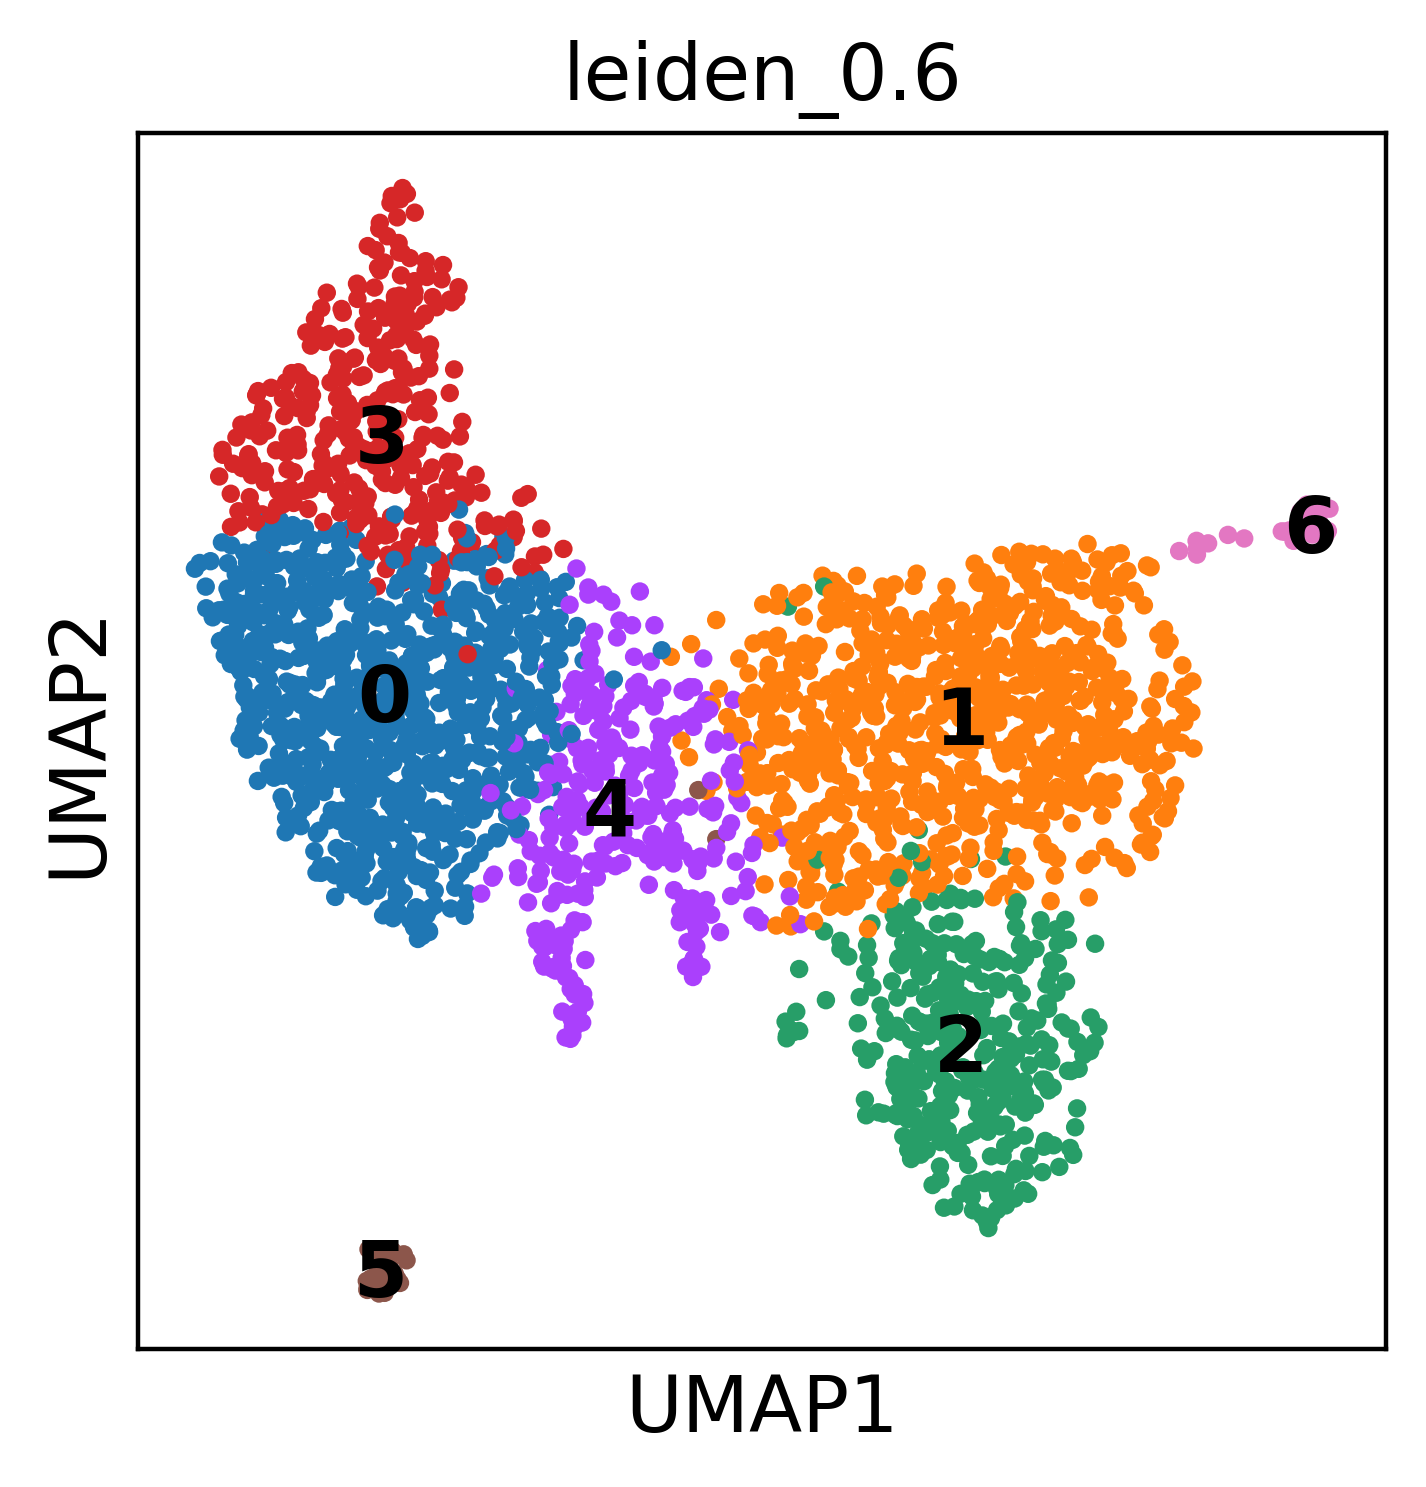

/shared/home/ssarnata/.conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


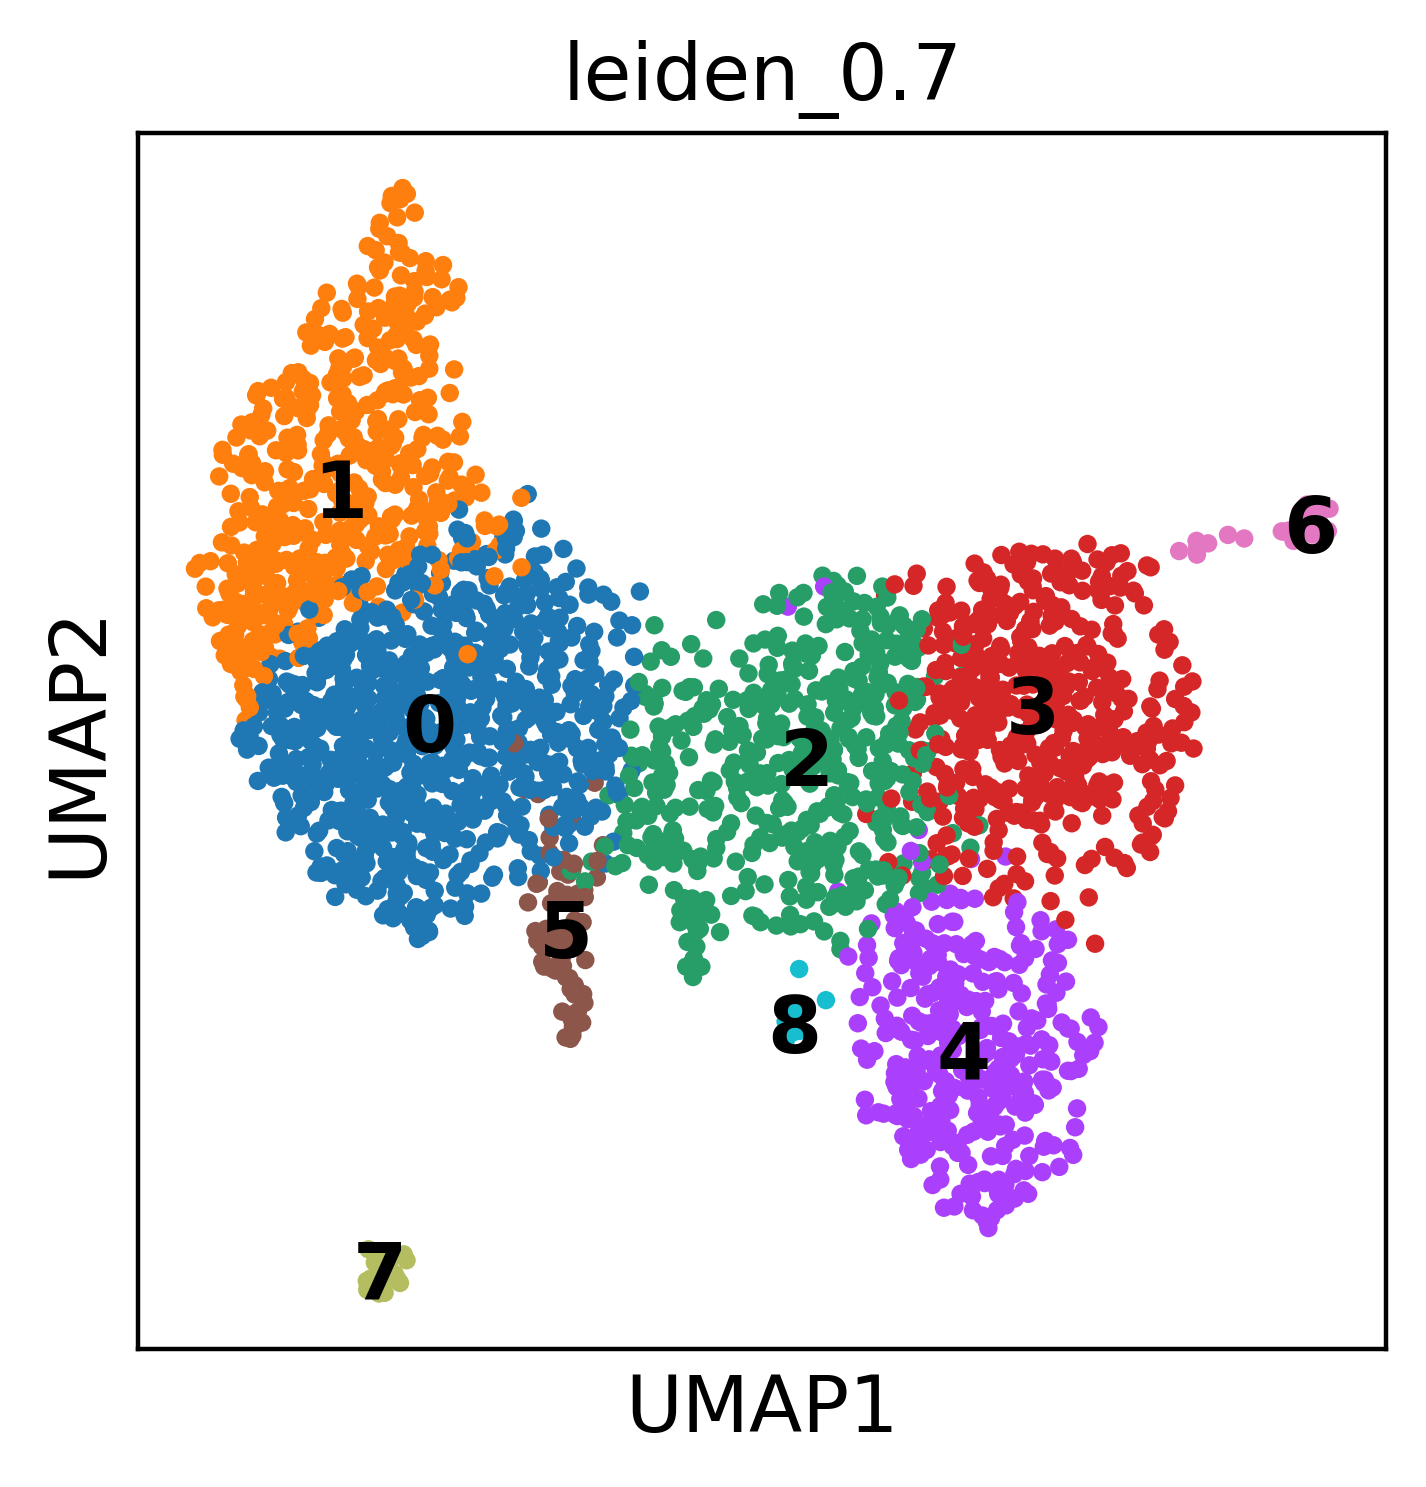

/shared/home/ssarnata/.conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


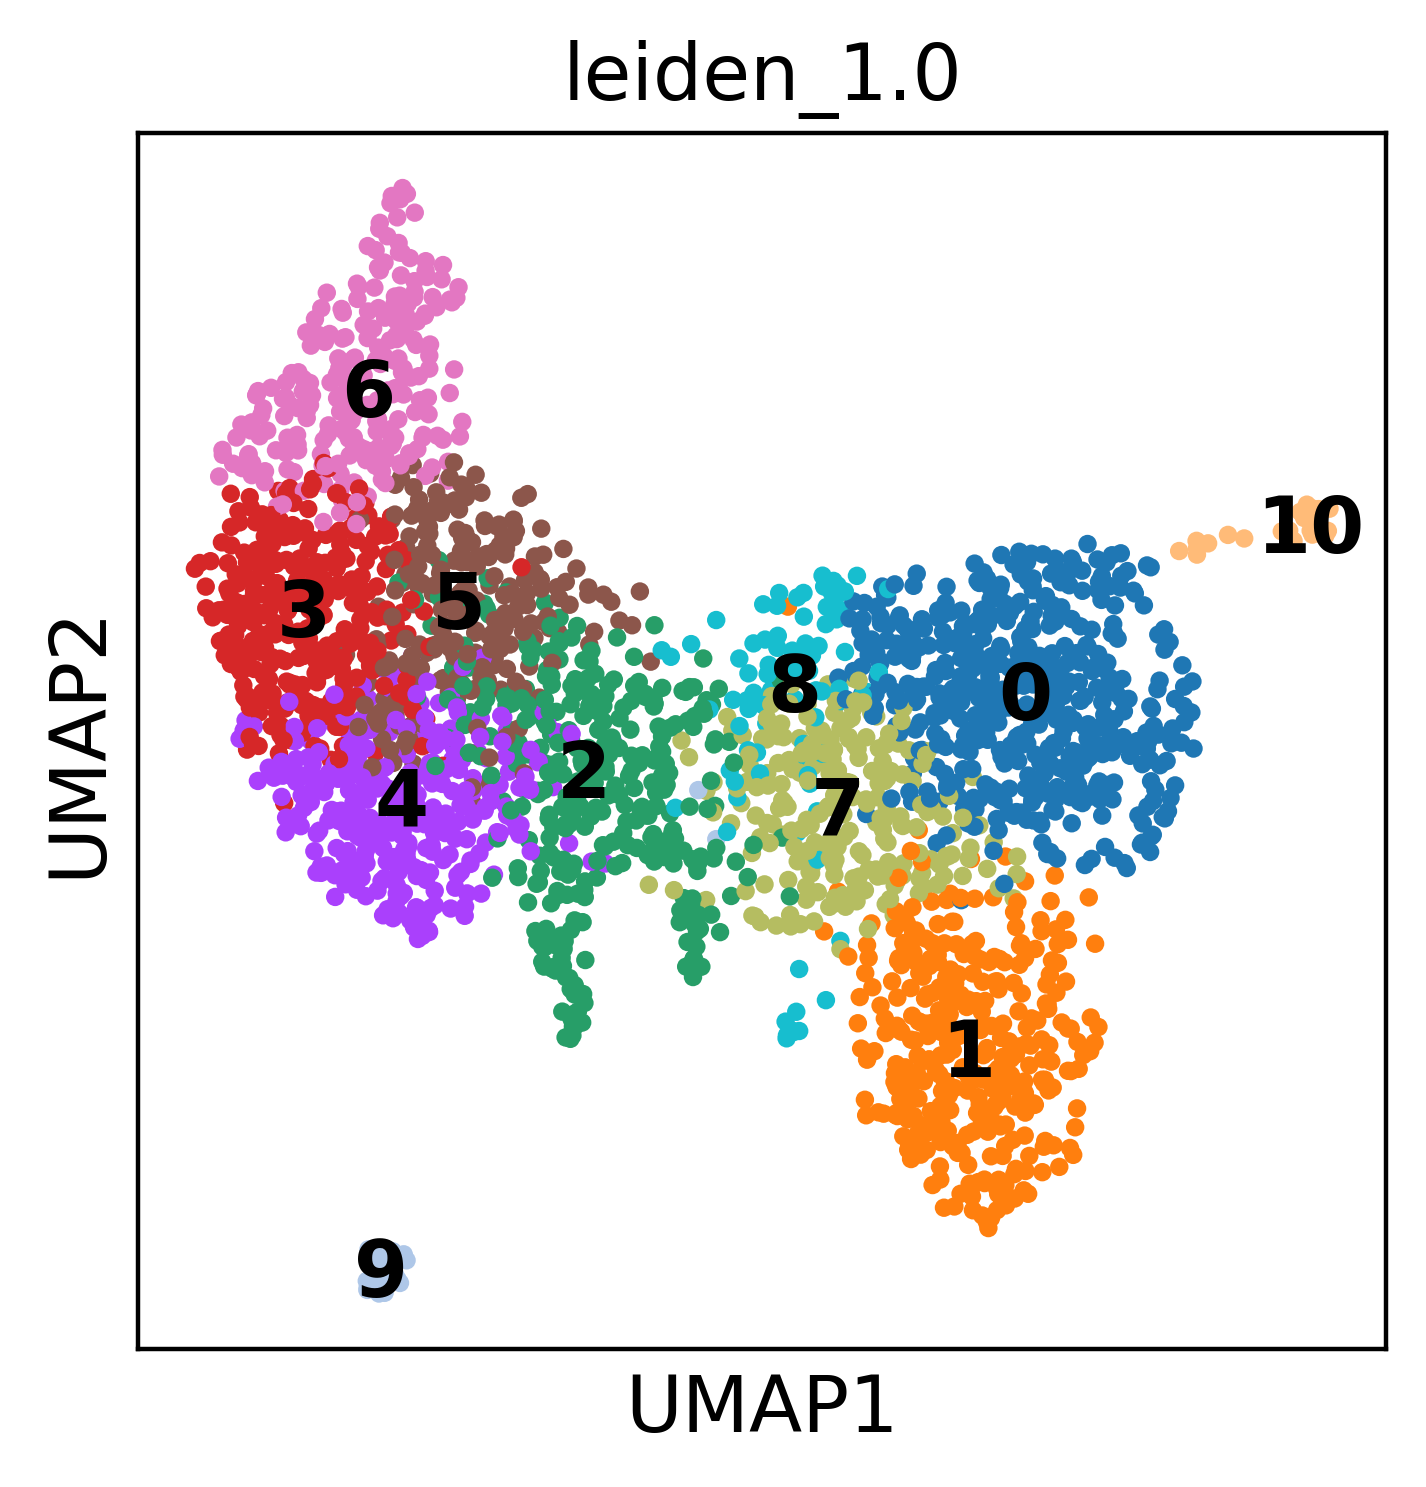

In [35]:
for res in [0.6,0.7,1.0]:
    sc.tl.leiden(adata, key_added="leiden_%s" %res, resolution=res)
    sc.pl.umap(adata, color="leiden_%s" %res,legend_loc="on data")